# Air Quality Prediction in Moroccan Cities
Analyse complete des donnees et des modeles ML.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/clean_data.csv')
print(f'Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes')
df.head()

Dataset : 480 lignes, 9 colonnes


,timestamp,city,temperature,humidity,pressure,wind_speed,aqi,pm2_5,city_encoded
0,2026-05-07 15:16:05,Fes,0.0,0.777778,0.75,0.146893,2,1.89,1
1,2026-05-07 14:16:05,Fes,0.0,0.777778,0.75,0.146893,2,1.90,1
2,2026-05-07 13:16:05,Fes,0.0,0.777778,0.75,0.146893,2,1.95,1
3,2026-05-07 12:16:05,Fes,0.0,0.777778,0.75,0.146893,2,2.06,1
4,2026-05-07 11:16:05,Fes,0.0,0.777778,0.75,0.146893,2,2.06,1


C:\Users\ouafi\AppData\Local\Temp\ipykernel_22324\151119650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='pm2_5', palette='Set2')


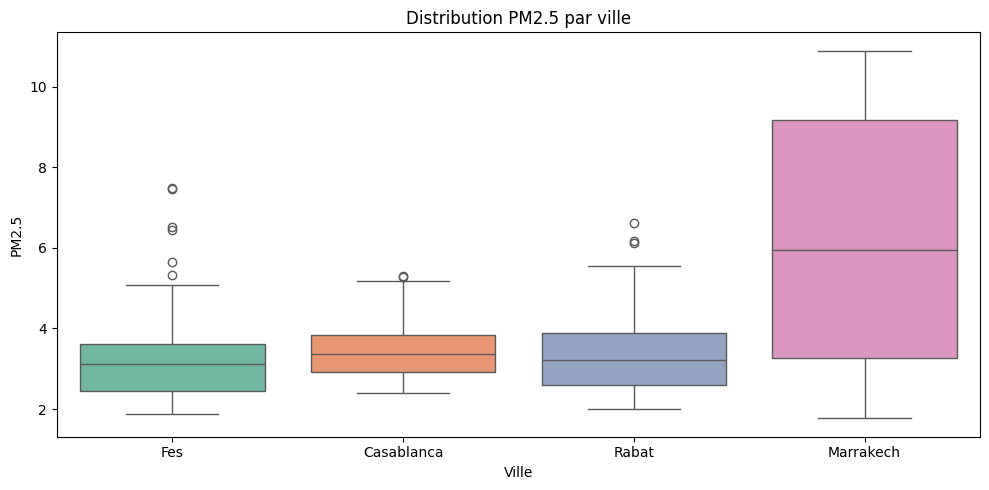

In [10]:
# Distribution PM2.5 par ville
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='city', y='pm2_5', palette='Set2')
plt.title('Distribution PM2.5 par ville')
plt.xlabel('Ville')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

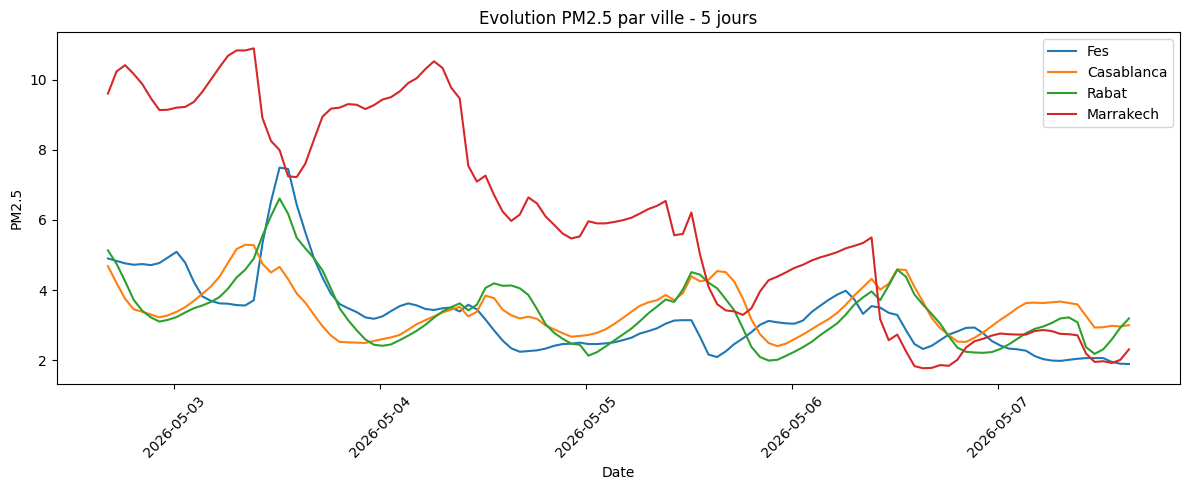

In [11]:
# Evolution PM2.5 dans le temps
df['timestamp'] = pd.to_datetime(df['timestamp'])
plt.figure(figsize=(12,5))
for city in df['city'].unique():
    city_df = df[df['city']==city].sort_values('timestamp')
    plt.plot(city_df['timestamp'], city_df['pm2_5'], label=city)
plt.title('Evolution PM2.5 par ville - 5 jours')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

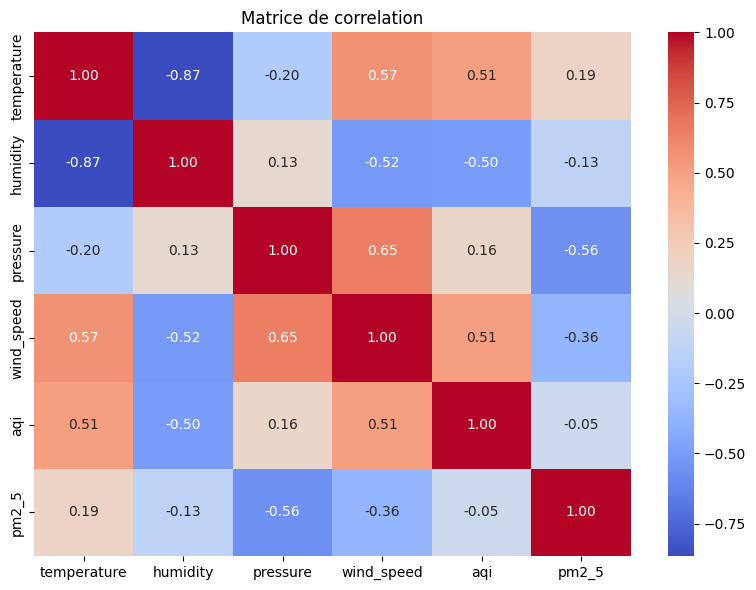

In [12]:
# Matrice de correlation
cols = ['temperature','humidity','pressure','wind_speed','aqi','pm2_5']
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

In [13]:
# Statistiques descriptives
cols = ['temperature','humidity','pressure','wind_speed','aqi','pm2_5']
df[cols].describe().round(2)

,temperature,humidity,pressure,wind_speed,aqi,pm2_5
count,480.00,480.00,480.00,480.00,480.00,480.00
mean,0.53,0.30,0.62,0.39,2.08,4.04
std,0.31,0.34,0.38,0.35,0.51,2.03
min,0.00,0.00,0.00,0.00,1.00,1.77
25%,0.42,0.13,0.56,0.11,2.00,2.73
50%,0.56,0.17,0.75,0.36,2.00,3.42
75%,0.67,0.32,0.81,0.58,2.00,4.52
max,1.00,1.00,1.00,1.00,3.00,10.89


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = ['temperature','humidity','pressure','wind_speed','city_encoded']
X = df[features]
y = df['pm2_5']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

for name, pred in [('Linear Regression', lr.predict(X_test)), ('Random Forest', rf.predict(X_test))]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f'{name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}')

Linear Regression: MAE=1.0874 | RMSE=1.6216 | R2=0.4589
Random Forest: MAE=1.0954 | RMSE=1.6342 | R2=0.4505


## Conclusion
- **Random Forest** performe mieux que Linear Regression
- La variable **AQI** est la plus correlee avec PM2.5
- **Marrakech** presente les valeurs PM2.5 les plus elevees
- Limite : donnees meteo statiques — un dataset plus varie ameliorerait les modeles